In [235]:
import pandas as pd
from pathlib import Path

DOWNLOADS = Path.home() / "Downloads"
stress = pd.read_csv(DOWNLOADS / "stress_weeklies_aug2024nov2025.csv")
list(stress.columns)

['name', 'date_range', 'total_stress_high']

In [236]:
ID_COL = "name"
DATE_RANGE_COL = "date_range"
STRESS_COL = "total_stress_high"

In [237]:
# Split date_range into start and end
stress[["week_start", "week_end"]] = (stress[DATE_RANGE_COL].str.split(" to ", expand=True))

# Convert to datetime
stress["week_start"] = pd.to_datetime(stress["week_start"])
stress["week_end"] = pd.to_datetime(stress["week_end"])

stress.head()

,name,date_range,total_stress_high,week_start,week_end
0,10200,2024-09-16 to 2024-10-28,31500,2024-09-16,2024-10-28
1,10200,2024-09-23 to 2024-11-04,45900,2024-09-23,2024-11-04
2,10200,2024-09-30 to 2024-11-11,45900,2024-09-30,2024-11-11
3,10200,2024-10-07 to 2024-11-18,37800,2024-10-07,2024-11-18
4,10200,2024-10-14 to 2024-11-25,23400,2024-10-14,2024-11-25


In [238]:
print("participants:", stress[ID_COL].nunique())
print("participant-weeks:", stress.shape[0]) #number of rows aka weeks

stress[STRESS_COL].describe()

participants: 327
participant-weeks: 12129


count     12129.000000
mean      56147.860500
std       37707.800207
min           0.000000
25%       30600.000000
50%       52200.000000
75%       77400.000000
max      300600.000000
Name: total_stress_high, dtype: float64

In [239]:
sleep = pd.read_csv(DOWNLOADS / "sleepsd_weeklies_aug2024nov2025.csv")
list(sleep.columns)

['name', 'date_range', 'SD_bedtime_start', 'SD_bedtime_end']

In [240]:
sleep[["week_start", "week_end"]] = (sleep["date_range"].str.split(" to ", expand=True))

sleep["week_start"] = pd.to_datetime(sleep["week_start"])
sleep["week_end"] = pd.to_datetime(sleep["week_end"])

sleep.head()

,name,date_range,SD_bedtime_start,SD_bedtime_end,week_start,week_end
0,10200,2024-09-09 to 2024-10-21,0:01:45,0:20:32,2024-09-09,2024-10-21
1,10200,2024-09-16 to 2024-10-28,0:17:42,0:39:06,2024-09-16,2024-10-28
2,10200,2024-09-23 to 2024-11-04,0:31:05,0:27:08,2024-09-23,2024-11-04
3,10200,2024-09-30 to 2024-11-11,0:49:19,0:10:22,2024-09-30,2024-11-11
4,10200,2024-10-07 to 2024-11-18,0:34:59,0:46:50,2024-10-07,2024-11-18


In [241]:
SLEEPSTART_COL = "SD_bedtime_start"

In [242]:
stress_sleep = stress.merge(sleep[[ID_COL, "week_start", "week_end", SLEEPSTART_COL]],on=[ID_COL, "week_start", "week_end"],how="left")

stress_sleep.shape

(12129, 6)

In [243]:
stress_sleep[[STRESS_COL, SLEEPSTART_COL]].isna().mean()

total_stress_high    0.000000
SD_bedtime_start     0.646467
dtype: float64

In [244]:
exercise = pd.read_csv(DOWNLOADS / "exercise_weeklies_aug2024nov2025.csv")
list(exercise.columns)

['name',
 'week_start',
 'active_calories',
 'high_activity_time',
 'medium_activity_time',
 'low_activity_time',
 'resting_time',
 'sedentary_time',
 'steps',
 'non_wear_time',
 'inactive_time',
 'date_range']

In [245]:
# parse date_range for exercise
exercise[["week_start", "week_end"]] = (exercise["date_range"].str.split(" to ", expand=True))
exercise["week_start"] = pd.to_datetime(exercise["week_start"])
exercise["week_end"] = pd.to_datetime(exercise["week_end"])

# exercise metric column
EXERCISECAL_COL = "active_calories"  # could use a different metric from columns in exercise

# merge into stress_sleep df
stress_sleep_ex = stress_sleep.merge(exercise[[ID_COL, "week_start", "week_end", EXERCISECAL_COL]],on=[ID_COL, "week_start", "week_end"],how="left")

stress_sleep_ex.shape

(12129, 7)

In [246]:
# inspect a few date ranges side by side
stress[[ID_COL, "week_start", "week_end"]].head(5)
exercise[[ID_COL, "week_start", "week_end"]].head(5)

,name,week_start,week_end
0,10200,2024-09-09,2024-09-15
1,10200,2024-09-16,2024-09-22
2,10200,2024-09-23,2024-09-29
3,10200,2024-09-30,2024-10-06
4,10200,2024-10-07,2024-10-13


In [247]:
stress_sleep_ex[[STRESS_COL, SLEEPSTART_COL, EXERCISECAL_COL]].isna().mean()

total_stress_high    0.000000
SD_bedtime_start     0.646467
active_calories      1.000000
dtype: float64

In [248]:
exercise_person = (
    exercise
    .groupby(ID_COL)[EXERCISECAL_COL]
    .mean()
    .reset_index()
    .rename(columns={EXERCISECAL_COL: "mean_active_calories"})
)

stress_sleep_ex = stress_sleep.merge(exercise_person,on=ID_COL,how="left")

stress_sleep_ex[[STRESS_COL, SLEEPSTART_COL, "mean_active_calories"]].isna().mean()

total_stress_high       0.000000
SD_bedtime_start        0.646467
mean_active_calories    0.000000
dtype: float64

In [249]:
stress_sleep["SD_bedtime_start_td"] = pd.to_timedelta(stress_sleep[SLEEPSTART_COL])

stress_sleep["SD_bedtime_start_min"] = (stress_sleep["SD_bedtime_start_td"].dt.total_seconds() / 60)

stress_sleep["SD_bedtime_start_min"].describe()

count    4288.000000
mean       82.317199
std        78.158603
min         0.000000
25%        41.625000
50%        63.700000
75%        94.437500
max       719.183333
Name: SD_bedtime_start_min, dtype: float64

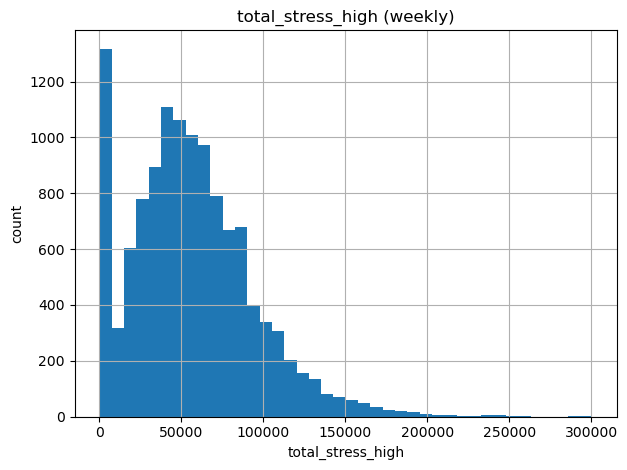

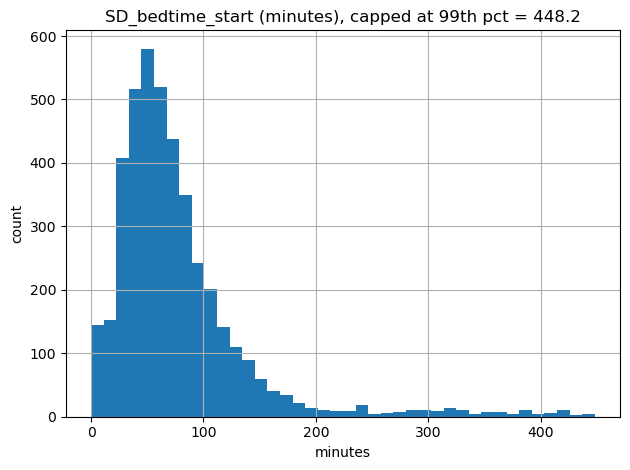

Sleep minutes cap (99th percentile): 448.23


In [250]:
import matplotlib.pyplot as plt
import numpy as np

# stress histogram
plt.figure()
stress_sleep[STRESS_COL].dropna().hist(bins=40)
plt.title(f"{STRESS_COL} (weekly)")
plt.xlabel(STRESS_COL)
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / f"hist_{STRESS_COL}.png", dpi=200)
plt.show()

# sleep SD histogram (minutes) with outlier-safe x-axis
sleep_min = stress_sleep["SD_bedtime_start_min"].dropna()

# cap x-axis for visualization so the max=719 min doesn't flatten everything
x_cap = sleep_min.quantile(0.99)  # data-driven cap

plt.figure()
sleep_min.hist(bins=40, range=(0, x_cap))
plt.title(f"SD_bedtime_start (minutes), capped at 99th pct = {x_cap:.1f}")
plt.xlabel("minutes")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / "hist_SD_bedtime_start_min_capped.png", dpi=200)
plt.show()

print("Sleep minutes cap (99th percentile):", round(x_cap, 2))

In [251]:
from pathlib import Path
import pandas as pd
import numpy as np

DOWNLOADS = Path.home() / "Downloads"

# list candidate exports
cands = [p for p in DOWNLOADS.glob("*.csv") if "week" in p.name.lower() or "Jan26" in p.name or "weeklies" in p.name.lower()]
[c.name for c in cands][:20]

['missingplusaug2024nov2025weeklies.csv',
 'cleaned_weeklydata (1).csv',
 'stress_weeklies_aug2024nov2025.csv',
 'cleaned_weeklydata.csv',
 'StudyOnTypicallyIgno-Jan26weeklies_DATA_2026-01-04_0526.csv',
 'sleepsd_weeklies_aug2024nov2025.csv',
 'exercise_weeklies_aug2024nov2025.csv']

In [252]:
weeklies_fp = DOWNLOADS / "StudyOnTypicallyIgno-Jan26weeklies_DATA_2026-01-04_0526.csv"  
weeklies = pd.read_csv(weeklies_fp)

weeklies.shape, list(weeklies.columns)[:40]

((10950, 94),
 ['participant_id',
  'redcap_event_name',
  'redcap_survey_identifier',
  'weekly_som_survey_timestamp',
  'id_num',
  'events___1',
  'events___3',
  'events___4',
  'events___0',
  'no_ovulation',
  'period_start',
  'period_end',
  'menzie_start',
  'period_end_date',
  'day_off',
  'need_dayoff',
  'pms___1',
  'pms___13',
  'pms___14',
  'pms___21',
  'pms___15',
  'pms___25',
  'pms___16',
  'pms___23',
  'pms___24',
  'pms___18',
  'pms___19',
  'pms___4',
  'pms___20',
  'pms___8',
  'pms___99',
  'pms___0',
  'pms_2___1',
  'pms_2___26',
  'pms_2___25',
  'pms_2___23',
  'pms_2___24',
  'pms_2___99',
  'pms_2___0',
  'writein_pms'])

In [253]:
ID_COL = "id_num"

In [254]:
# cycle starts from menzie_start
cycles = weeklies[[ID_COL, "menzie_start"]].copy()

# parse dates safely
cycles["menzie_start"] = pd.to_datetime(cycles["menzie_start"], errors="coerce")
cycles["menzie_start"].dtype

# drop rows without a cycle start
cycles = cycles.dropna(subset=["menzie_start"])

# sort within participant
cycles = cycles.sort_values([ID_COL, "menzie_start"])

cycles.head()

,id_num,menzie_start
9547,0,2025-04-15
10907,0,2025-11-06
557,0,2025-11-16
1221,100208,2025-03-30
6511,10103,2025-04-03


In [255]:
cycles.groupby(ID_COL).size().describe()

count    353.000000
mean       7.943343
std        5.673119
min        1.000000
25%        3.000000
50%        7.000000
75%       12.000000
max       28.000000
dtype: float64

In [256]:
cycles["menzie_start"].describe()

count                             2813
mean     2025-05-25 11:56:09.640952576
min                2023-12-09 00:00:00
25%                2025-02-28 00:00:00
50%                2025-05-19 00:00:00
75%                2025-08-29 00:00:00
max                2026-01-01 00:00:00
Name: menzie_start, dtype: object

In [257]:
cycles["menzie_start"] = pd.to_datetime(cycles["menzie_start"],errors="coerce",utc=False)

cycles["menzie_start"].dtype

dtype('<M8[ns]')

In [258]:
cycles.dtypes

id_num                  object
menzie_start    datetime64[ns]
dtype: object

In [259]:
import pandas.api.types as ptypes
ptypes.is_datetime64_any_dtype(cycles["menzie_start"])

True

In [260]:
# sorted
cycles = cycles.sort_values([ID_COL, "menzie_start"])

# cycle length in days
cycles["cycle_length_days"] = (cycles.groupby(ID_COL)["menzie_start"].diff().dt.days)

# drop first start per person so no previous cycle
cycles2 = cycles.dropna(subset=["cycle_length_days"]).copy()

cycles2["cycle_length_days"].describe()

count    2451.000000
mean       28.542636
std        26.994832
min         0.000000
25%        22.000000
50%        28.000000
75%        32.000000
max       395.000000
Name: cycle_length_days, dtype: float64

In [261]:
cycles2["cycle_length_days"].min(), cycles2["cycle_length_days"].max()

(0.0, 395.0)

In [262]:
(cycles2["cycle_length_days"] < 10).mean(), (cycles2["cycle_length_days"] > 90).mean()

(np.float64(0.19869441044471645), np.float64(0.022031823745410038))

In [263]:
cycles_nodup = cycles.drop_duplicates(subset=[ID_COL, "menzie_start"]).copy()
cycles_nodup = cycles_nodup.sort_values([ID_COL, "menzie_start"])

cycles_nodup["cycle_length_days"] = (cycles_nodup.groupby(ID_COL)["menzie_start"].diff().dt.days)

cycles2 = cycles_nodup.dropna(subset=["cycle_length_days"]).copy()
cycles2["cycle_length_days"].describe()

count    2099.000000
mean       33.329204
std        26.294036
min         1.000000
25%        25.000000
50%        29.000000
75%        33.000000
max       395.000000
Name: cycle_length_days, dtype: float64

In [264]:
(cycles2["cycle_length_days"] < 10).mean(), (cycles2["cycle_length_days"] > 90).mean()

(np.float64(0.06431634111481659), np.float64(0.02572653644592663))

In [265]:
cycles2_qc = cycles2.query("cycle_length_days >= 10 and cycle_length_days <= 90").copy()

cycles2_qc["cycle_length_days"].describe()

count    1910.000000
mean       32.108901
std        12.136368
min        10.000000
25%        26.000000
50%        29.000000
75%        33.000000
max        90.000000
Name: cycle_length_days, dtype: float64

In [266]:
cycle_reg = (cycles2_qc.groupby(ID_COL)["cycle_length_days"].agg(mean_cycle_length="mean", sd_cycle_length="std", n_cycles="count").reset_index())

# participants with enough cycles to estimate SD
cycle_reg = cycle_reg[cycle_reg["n_cycles"] >= 3].copy()

cycle_reg.describe()
cycle_reg.head()

,id_num,mean_cycle_length,sd_cycle_length,n_cycles
1,10199,29.250000,2.362908,4
2,10200,24.000000,1.878673,18
3,10201,60.666667,24.172988,3
5,10203,34.200000,17.164563,10
6,10204,33.900000,7.894442,10


In [267]:
stress_person = (stress_sleep.groupby("name")[STRESS_COL].mean().reset_index().rename(columns={STRESS_COL: "mean_total_stress_high"}))

stress_person.head()

,name,mean_total_stress_high
0,10200,44314.285714
1,10201,37980.000000
2,10202,39057.142857
3,10203,73262.686567
4,10205,54053.731343


In [268]:
# stress_person uses id_num
stress_person = stress_person.rename(columns={"name": "id_num"}).copy()

stress_person["id_num"] = pd.to_numeric(stress_person["id_num"], errors="coerce")

stress_person.head()
stress_person["id_num"].isna().mean()

np.float64(0.0)

In [269]:
cycle_reg.columns

Index(['id_num', 'mean_cycle_length', 'sd_cycle_length', 'n_cycles'], dtype='object')

In [270]:
bg_fp = DOWNLOADS / "cleaned_backgrounddata.csv"
background = pd.read_csv(bg_fp)

background.shape
background.columns

Index(['participant_id', 'redcap_event_name', 'redcap_repeat_instrument',
       'redcap_repeat_instance', 'id_num', 'address', 'ring', 'years',
       'gender', 'weight',
       ...
       'sport___82', 'sport___83', 'non_athlete_exercise',
       'intensity_freq___1', 'intensity_freq___2', 'intensity_freq___3',
       'intensity_freq___4', 'strength', 'strength_days', 'strength_groups'],
      dtype='object', length=204)

In [271]:
AGE_COL = "years"
HEIGHT_COL = "height" #inches
WEIGHT_COL = "weight" #pounds

background[HEIGHT_COL] = pd.to_numeric(background[HEIGHT_COL], errors="coerce")
background[WEIGHT_COL] = pd.to_numeric(background[WEIGHT_COL], errors="coerce")

background["bmi"] = (background[WEIGHT_COL] / (background[HEIGHT_COL]**2)) * 703
BMI_COL = "bmi"

background[[AGE_COL, BMI_COL]].describe()

,years,bmi
count,301.000000,301.000000
mean,28.910299,26.430855
std,6.927861,6.211469
min,18.000000,16.945592
25%,23.000000,22.296331
50%,29.000000,25.056806
75%,33.000000,29.118343
max,50.000000,51.997041


In [272]:
background[HEIGHT_COL].describe(), background[WEIGHT_COL].describe()

(count    301.000000
 mean      64.613289
 std        3.772429
 min       51.000000
 25%       63.000000
 50%       65.000000
 75%       67.000000
 max       74.000000
 Name: height, dtype: float64,
 count    301.000000
 mean     156.043189
 std       34.325910
 min      100.000000
 25%      134.000000
 50%      150.000000
 75%      177.000000
 max      350.000000
 Name: weight, dtype: float64)

In [273]:
# covariates table
covars = (background[["id_num", AGE_COL, BMI_COL]].copy())

covars["id_num"] = pd.to_numeric(covars["id_num"], errors="coerce")
covars = covars.dropna(subset=["id_num"])
covars = covars.drop_duplicates(subset=["id_num"])

covars.head()

,id_num,years,bmi
0,10216.0,24.0,30.680421
1,10291.0,33.0,31.882086
2,10206.0,33.0,28.032301
3,10247.0,38.0,38.405307
4,10214.0,30.0,25.237773


In [274]:
# force consistent merge key dtype
for df, name in [(cycle_reg, "cycle_reg"), (stress_person, "stress_person"), (covars, "covars")]:df["id_num"] = pd.to_numeric(df["id_num"], errors="coerce")
print(name, df["id_num"].dtype, df["id_num"].isna().mean())

covars float64 0.0


In [275]:
# regression dataframe
df_reg = (cycle_reg.merge(stress_person, on="id_num", how="left").merge(covars, on="id_num", how="left"))

df_reg.shape
df_reg.head()

,id_num,mean_cycle_length,sd_cycle_length,n_cycles,mean_total_stress_high,years,bmi
0,10199.0,29.250000,2.362908,4,NaN,26.0,28.971931
1,10200.0,24.000000,1.878673,18,44314.285714,46.0,26.700832
2,10201.0,60.666667,24.172988,3,37980.000000,19.0,20.117066
3,10203.0,34.200000,17.164563,10,73262.686567,32.0,21.214360
4,10204.0,33.900000,7.894442,10,NaN,22.0,36.397929


In [276]:
# missingness
df_reg[["sd_cycle_length","mean_total_stress_high",AGE_COL,BMI_COL]].isna().mean()

sd_cycle_length           0.000000
mean_total_stress_high    0.053571
years                     0.084821
bmi                       0.084821
dtype: float64

In [277]:
dfm = df_reg.dropna(subset=["sd_cycle_length", "mean_total_stress_high", AGE_COL, BMI_COL]).copy()

dfm.shape

(195, 7)

In [278]:
import statsmodels.formula.api as smf

model = smf.ols(f"sd_cycle_length ~ mean_total_stress_high + {AGE_COL} + {BMI_COL}",data=dfm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.212
Date:                Thu, 15 Jan 2026   Prob (F-statistic):              0.307
Time:                        13:43:19   Log-Likelihood:                -658.30
No. Observations:                 195   AIC:                             1325.
Df Residuals:                     191   BIC:                             1338.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 15

In [279]:
# z-score helpers
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

# z-score predictors
dfm = dfm.copy()
dfm["stress_z"] = zscore(dfm["mean_total_stress_high"])
dfm["age_z"]    = zscore(dfm[AGE_COL])
dfm["bmi_z"]    = zscore(dfm[BMI_COL])

dfm[["stress_z", "age_z", "bmi_z"]].describe()

,stress_z,age_z,bmi_z
count,1.950000e+02,1.950000e+02,1.950000e+02
mean,-1.093143e-16,1.503071e-16,-5.101332e-16
std,1.002574e+00,1.002574e+00,1.002574e+00
min,-2.214155e+00,-1.548364e+00,-1.546034e+00
25%,-7.291140e-01,-7.965440e-01,-6.440089e-01
50%,-8.095282e-02,-4.472367e-02,-1.826757e-01
75%,7.381676e-01,5.567326e-01,4.074646e-01
max,3.265871e+00,2.962558e+00,4.485345e+00


In [280]:
dfm[["stress_z", "age_z", "bmi_z"]].agg(["mean","std"])

,stress_z,age_z,bmi_z
mean,-1.093143e-16,1.503071e-16,-5.101332e-16
std,1.002574e+00,1.002574e+00,1.002574e+00


In [281]:
import statsmodels.formula.api as smf

model_z = smf.ols(
    "sd_cycle_length ~ stress_z + age_z + bmi_z",
    data=dfm
).fit()

print(model_z.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.212
Date:                Thu, 15 Jan 2026   Prob (F-statistic):              0.307
Time:                        13:43:19   Log-Likelihood:                -658.30
No. Observations:                 195   AIC:                             1325.
Df Residuals:                     191   BIC:                             1338.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.2645      0.512     20.043      0.0

In [282]:
print("SLEEPSTART_COL =", SLEEPSTART_COL)
stress_sleep[SLEEPSTART_COL].head(10), stress_sleep[SLEEPSTART_COL].dtype

SLEEPSTART_COL = SD_bedtime_start


(0    0:17:42
 1    0:31:05
 2    0:49:19
 3    0:34:59
 4    0:44:14
 5    0:38:29
 6    0:47:08
 7    0:22:12
 8    0:24:07
 9    0:47:36
 Name: SD_bedtime_start, dtype: object,
 dtype('O'))

In [283]:
# make a numeric minutes column from SLEEPSTART_COL
sleep_raw = stress_sleep[SLEEPSTART_COL]

if np.issubdtype(sleep_raw.dtype, np.number):
    # already numeric
    stress_sleep["sleepstart_sd_min"] = sleep_raw
else:
    stress_sleep["sleepstart_sd_min"] = (
        pd.to_timedelta(sleep_raw, errors="coerce").dt.total_seconds() / 60)

stress_sleep["sleepstart_sd_min"].describe()
stress_sleep[["name", SLEEPSTART_COL, "sleepstart_sd_min"]].head(10)

,name,SD_bedtime_start,sleepstart_sd_min
0,10200,0:17:42,17.700000
1,10200,0:31:05,31.083333
2,10200,0:49:19,49.316667
3,10200,0:34:59,34.983333
4,10200,0:44:14,44.233333
5,10200,0:38:29,38.483333
6,10200,0:47:08,47.133333
7,10200,0:22:12,22.200000
8,10200,0:24:07,24.116667
9,10200,0:47:36,47.600000


In [284]:
sleep_person = (stress_sleep.groupby("name")["sleepstart_sd_min"].mean().reset_index()
    .rename(columns={
        "name": "id_num",
        "sleepstart_sd_min": "mean_sleepstart_sd_min"
    })
)

sleep_person["id_num"] = pd.to_numeric(sleep_person["id_num"], errors="coerce")
sleep_person.head()
sleep_person.shape

(327, 2)

In [285]:
df_reg_sleep = (cycle_reg.merge(sleep_person, on="id_num", how="left").merge(covars, on="id_num", how="left"))

df_reg_sleep[["sd_cycle_length", "mean_sleepstart_sd_min", AGE_COL, BMI_COL]].isna().mean()

dfm_sleep = df_reg_sleep.dropna(subset=["sd_cycle_length", "mean_sleepstart_sd_min", AGE_COL, BMI_COL]).copy()

# z-score
dfm_sleep["sleep_z"] = zscore(dfm_sleep["mean_sleepstart_sd_min"])
dfm_sleep["age_z"]   = zscore(dfm_sleep[AGE_COL])
dfm_sleep["bmi_z"]   = zscore(dfm_sleep[BMI_COL])

model_sleep_z = smf.ols(
    "sd_cycle_length ~ sleep_z + age_z + bmi_z",
    data=dfm_sleep
).fit()

print(model_sleep_z.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.360
Date:                Thu, 15 Jan 2026   Prob (F-statistic):              0.261
Time:                        13:43:19   Log-Likelihood:                -284.37
No. Observations:                  83   AIC:                             576.7
Df Residuals:                      79   BIC:                             586.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.1177      0.837     12.083      0.0

In [291]:
# EXERCISE

exercise = pd.read_csv(DOWNLOADS / "exercise_weeklies_aug2024nov2025.csv")
exercise.columns

Index(['name', 'week_start', 'active_calories', 'high_activity_time',
       'medium_activity_time', 'low_activity_time', 'resting_time',
       'sedentary_time', 'steps', 'non_wear_time', 'inactive_time',
       'date_range'],
      dtype='object')

In [295]:
exercise["name"] = pd.to_numeric(exercise["name"], errors="coerce")

exercise_person = (exercise.groupby("name")["active_calories"].mean().reset_index().rename(columns={
        "name": "id_num",
        "active_calories": "mean_active_calories"
    })
)

exercise_person.head()
exercise_person.shape
exercise_person["mean_active_calories"].describe()

count      327.000000
mean      2840.043816
std       1176.318773
min         48.000000
25%       2044.039683
50%       2697.953488
75%       3485.254717
max      11913.642857
Name: mean_active_calories, dtype: float64

In [296]:
exercise_person = (exercise.groupby("name")["active_calories"].agg(mean_active_calories="mean", n_weeks_ex="count").reset_index().rename(columns={"name": "id_num"}))

exercise_person["id_num"] = pd.to_numeric(exercise_person["id_num"], errors="coerce")

exercise_person[["n_weeks_ex","mean_active_calories"]].describe()

,n_weeks_ex,mean_active_calories
count,327.000000,327.000000
mean,35.336391,2840.043816
std,19.419252,1176.318773
min,1.000000,48.000000
25%,17.000000,2044.039683
50%,42.000000,2697.953488
75%,50.000000,3485.254717
max,70.000000,11913.642857


In [298]:
df_reg_ex = (cycle_reg.merge(exercise_person, on="id_num", how="left").merge(covars, on="id_num", how="left"))

df_reg_ex[["sd_cycle_length","mean_active_calories", AGE_COL, BMI_COL]].isna().mean()

dfm_ex = df_reg_ex.dropna(subset=["sd_cycle_length","mean_active_calories", AGE_COL, BMI_COL]).copy()

dfm_ex["exercise_z"] = zscore(dfm_ex["mean_active_calories"])
dfm_ex["age_z"]      = zscore(dfm_ex[AGE_COL])
dfm_ex["bmi_z"]      = zscore(dfm_ex[BMI_COL])

model_ex = smf.ols("sd_cycle_length ~ exercise_z + age_z + bmi_z",data=dfm_ex).fit()

print(model_ex.summary())

                            OLS Regression Results                            
Dep. Variable:        sd_cycle_length   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     2.049
Date:                Thu, 15 Jan 2026   Prob (F-statistic):              0.108
Time:                        13:49:36   Log-Likelihood:                -657.05
No. Observations:                 195   AIC:                             1322.
Df Residuals:                     191   BIC:                             1335.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.2645      0.509     20.171      0.0

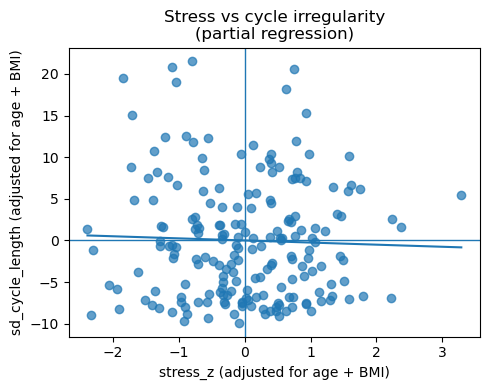

In [303]:
# stress regression plot (partial regression adjusted for age and BMI) 
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

# stress model dataframe = dfm
y_col = "sd_cycle_length"
x_col = "stress_z"
covars = ["age_z", "bmi_z"]

# residualize y and x on covariates
Xc = sm.add_constant(dfm[covars])
y_res = pd.Series(sm.OLS(dfm[y_col], Xc, missing="drop").fit().resid, index=dfm.index)
x_res = pd.Series(sm.OLS(dfm[x_col], Xc, missing="drop").fit().resid, index=dfm.index)

# fit line on residuals
line = sm.OLS(y_res, sm.add_constant(x_res)).fit()
intercept = float(line.params.iloc[0])
slope = float(line.params.iloc[1])

# plot
plt.figure(figsize=(5, 4))
plt.scatter(x_res, y_res, alpha=0.7)
xs = np.linspace(x_res.min(), x_res.max(), 200)
plt.plot(xs, intercept + slope * xs)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("stress_z (adjusted for age + BMI)")
plt.ylabel("sd_cycle_length (adjusted for age + BMI)")
plt.title("Stress vs cycle irregularity\n(partial regression)")
plt.tight_layout()
plt.show()

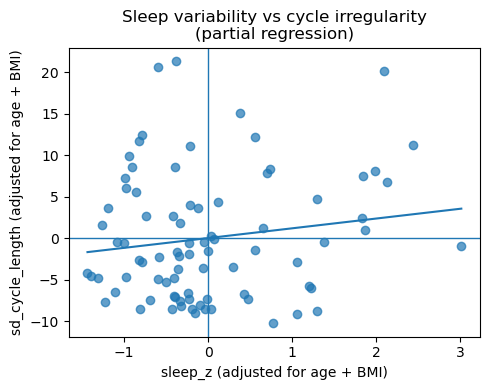

In [307]:
# sleep regression plot (partial regression adjusted for age and BMI)
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

# sleep model dataframe = dfm_sleep
y_col = "sd_cycle_length"
x_col = "sleep_z"
covars = ["age_z", "bmi_z"]

# residualize y and x on covariates
Xc = sm.add_constant(dfm_sleep[covars])
y_res = pd.Series(
    sm.OLS(dfm_sleep[y_col], Xc, missing="drop").fit().resid,
    index=dfm_sleep.index
)
x_res = pd.Series(
    sm.OLS(dfm_sleep[x_col], Xc, missing="drop").fit().resid,
    index=dfm_sleep.index
)

# fit line on residuals
line = sm.OLS(y_res, sm.add_constant(x_res)).fit()
intercept = float(line.params.iloc[0])
slope = float(line.params.iloc[1])

# plot
plt.figure(figsize=(5, 4))
plt.scatter(x_res, y_res, alpha=0.7)
xs = np.linspace(x_res.min(), x_res.max(), 200)
plt.plot(xs, intercept + slope * xs)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("sleep_z (adjusted for age + BMI)")
plt.ylabel("sd_cycle_length (adjusted for age + BMI)")
plt.title("Sleep variability vs cycle irregularity\n(partial regression)")
plt.tight_layout()
plt.show()

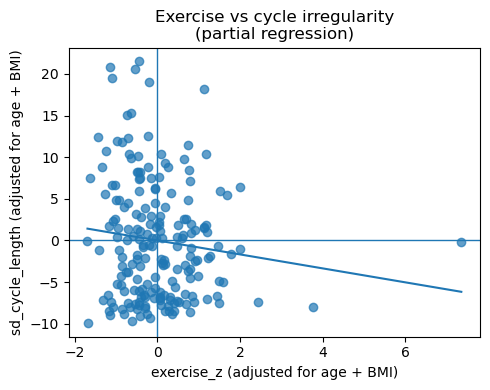

In [306]:
# exercise regression plot (partial regression adjusted for age and BMI)
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

# exercise model dataframe = dfm_ex
y_col = "sd_cycle_length"
x_col = "exercise_z"
covars = ["age_z", "bmi_z"]

# residualize y and x on covariates
Xc = sm.add_constant(dfm_ex[covars])
y_res = pd.Series(
    sm.OLS(dfm_ex[y_col], Xc, missing="drop").fit().resid,
    index=dfm_ex.index
)
x_res = pd.Series(
    sm.OLS(dfm_ex[x_col], Xc, missing="drop").fit().resid,
    index=dfm_ex.index
)

# fit line on residuals
line = sm.OLS(y_res, sm.add_constant(x_res)).fit()
intercept = float(line.params.iloc[0])
slope = float(line.params.iloc[1])

# plot
plt.figure(figsize=(5, 4))
plt.scatter(x_res, y_res, alpha=0.7)
xs = np.linspace(x_res.min(), x_res.max(), 200)
plt.plot(xs, intercept + slope * xs)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("exercise_z (adjusted for age + BMI)")
plt.ylabel("sd_cycle_length (adjusted for age + BMI)")
plt.title("Exercise vs cycle irregularity\n(partial regression)")
plt.tight_layout()
plt.show()